# Water Quality

Proje dünyada bulunan su kalitesinin tahminidir.

**Amaç:** suyun içerisinde bulunan farklı featureları kullanarak suyun içilebilir mi içilemez mi olduğunu anlamaya çalışmak.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # visualization
import matplotlib.pyplot as plt # visualization
import plotly.express as px # visualization

import missingno as msno # missing value analysis

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import precision_score, confusion_matrix

from sklearn import tree
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adityakadiwal/water-potability/water_potability.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/adityakadiwal/water-potability/water_potability.csv")

# EDA

EDA kapsamında incelenenler:
* veri setinin içinde bulunan temel bilgiler
* Target variable analysis
* korelasyon ve dağılıım
* missing value analysis

In [3]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [4]:
df.tail()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


In [5]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


ph → 3276 - 2785 = 491 adet missing value var.

toplamda 9 float 1 int var int olan potability (target) 

## Dependent Variable Analysis (bagimli degisken analizi)

In [7]:
d = pd.DataFrame(df["Potability"].value_counts())
# 1. d'nin indeksini sütuna dönüştürüyoruz, böylece Plotly indeks değerlerine erişebilir
d_clean = d.reset_index()

In [8]:
# Grafik çizimi (Sütun adlarını güncellenmiş yeni DataFrame'e göre ayarlıyoruz)
fig = px.pie(d_clean,       
             values="count",         # Pandas'ın oluşturduğu sayıların olduğu sütun
             names="Potability",     # Reset_index sonrası oluşan kategori sütunu (0 ve 1'ler)
             hole = 0.35,      
             opacity = 0.8,
             labels = {"count": "Number of Samples", "Potability": "Status"}
            )

fig.update_layout(title = dict(text = "Pie Chart of Potability Feature", x=0.5))
fig.update_traces(
    textposition = "outside", 
    textinfo = "percent+label", 
    labels = ["Not Potable", "Potable"]  # Sırasıyla 0 ve 1 değerlerini bu metinlerle eşler
)
fig.show()

fig.write_html("potability_pie_chart.html")

## Korelasyon Analizi

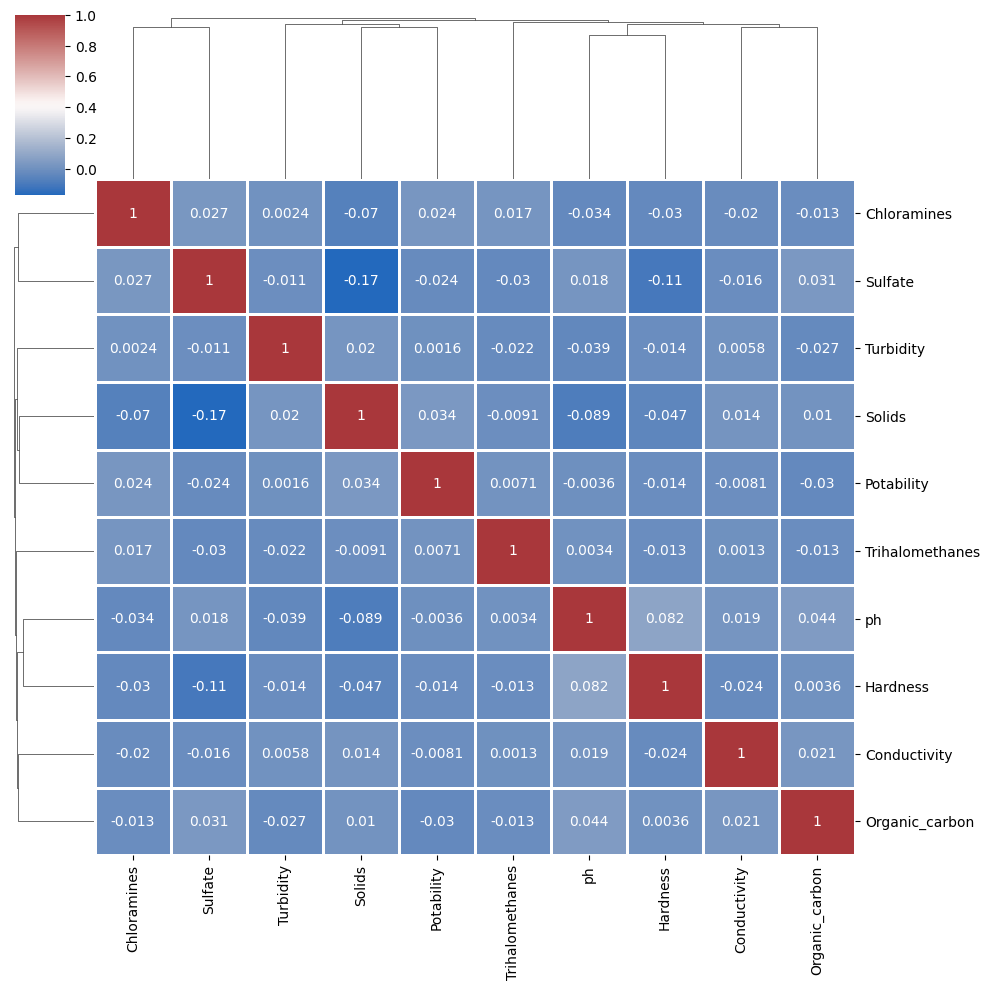

In [9]:
sns.clustermap(
    df.corr(), 
    cmap = "vlag", 
    dendrogram_ratio = (0.1,0.2),
    annot = True, 
    linewidths = 0.8,
    figsize = (10,10)
)
plt.show()

In [10]:
non_potable = df.query("Potability == 0")
potable = df.query("Potability == 1")

/tmp/ipykernel_16/1324387225.py:8: UserWarning:

Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations



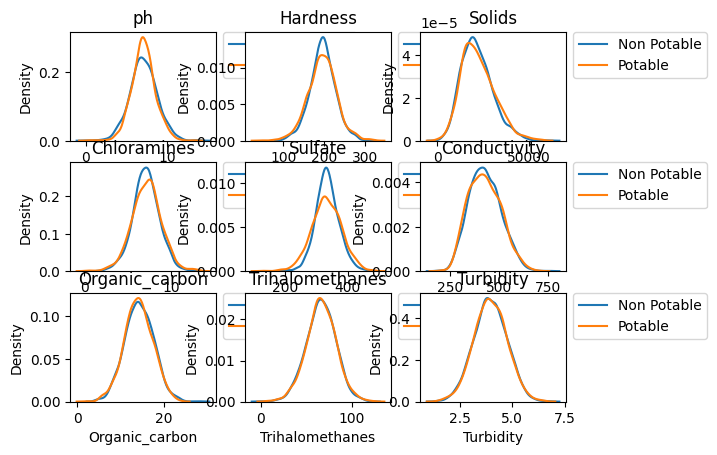

In [11]:
plt.figure()
for ax, col in enumerate(df.columns[:9]):
    plt.subplot(3,3, ax+1)
    plt.title(col)
    sns.kdeplot(x = non_potable[col], label = "Non Potable")
    sns.kdeplot(x = potable[col], label = "Potable")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

eksik  verilerden;
* ph: gauss dağılımına sahip
* sulfate: gauss dağılımına sahip
* trihalomethanes : gauss dağılımına sahip

yani gauss dağılımını bozmayacak şekilde bulunan missing valueları veri setindeki diğer dağılımların ortalamasına göre doldurabilirim

## Missing value

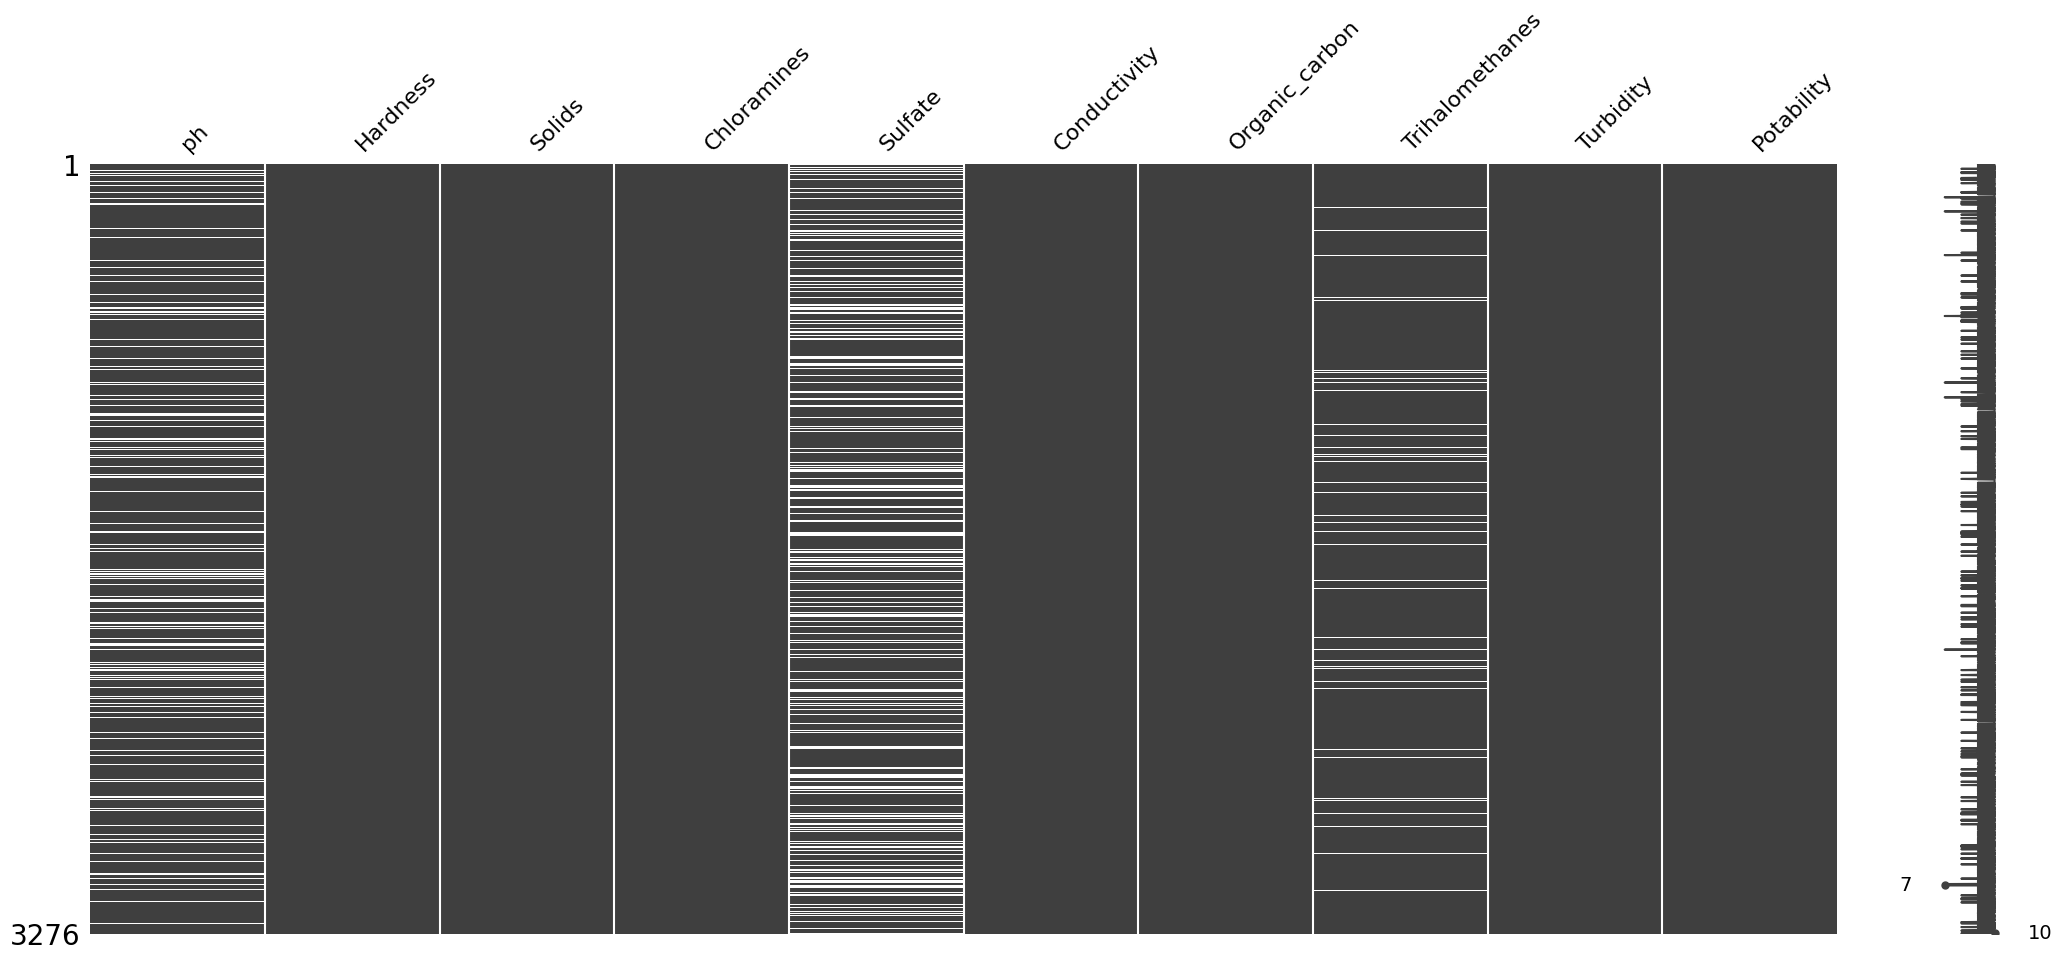

In [12]:
msno.matrix(df)
plt.show()

ph, sulfate, trihalomethanes için kayıp veri problemini çözmeliyiz.

# Preprocessing
missing value, train-test split, normalization

Bu aşamada yapılanlar:
* missing value problemi eksik olan üç veri (ph, Sulfate, Trihalomethanes) için de gruplara göre ortalama ile dolduruldu.
* veri train ve test olmak üzere ikiye ayırıldı.
* normalizasyon yapıldı

## missing value

In [13]:
print(df.isnull().sum())

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


dağılımlarına göre doldurulacak.

hepsinde gauss dağılımı var yani ortalamayla doldurulacak ve gruplarının ortalaması alınacak

In [14]:
df["ph"] = df["ph"].fillna(df.groupby("Potability")["ph"].transform("mean"))

In [15]:
df["Sulfate"] = df["Sulfate"].fillna(df.groupby("Potability")["Sulfate"].transform("mean"))

In [16]:
df["Trihalomethanes"] = df["Trihalomethanes"].fillna(df.groupby("Potability")["Trihalomethanes"].transform("mean"))

In [17]:
print(df.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


## train test split

In [18]:
# x independent values, y target value

X = df.drop("Potability", axis = 1).values
y = df["Potability"].values

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size = 0.3, # veri setinin ½30u test
    random_state = 42 # karışım 
)

In [20]:
print("X_train boyutu:", X_train.shape)
print("X_test boyutu :", X_test.shape)
print("y_train boyutu:", y_train.shape)
print("y_test boyutu :", y_test.shape)

X_train boyutu: (2293, 9)
X_test boyutu : (983, 9)
y_train boyutu: (2293,)
y_test boyutu : (983,)


## Normalization

min-max normalization yapılacak

In [21]:
x_train_max = np.max(X_train, axis=0)
x_train_min = np.min(X_train, axis=0)

X_train = (X_train - x_train_min) / (x_train_max - x_train_min)
X_test = (X_test - x_train_min) / (x_train_max - x_train_min)

In [22]:
np.set_printoptions(suppress=True, precision=4)
print("train\n")
print(X_train[:5])
print("\ntest\n")
print(X_test[:5])

train

[[0.5061 0.4605 0.4639 0.6058 0.7187 0.421  0.2593 0.4754 0.3309]
 [0.5145 0.3804 0.3653 0.4673 0.4059 0.4475 0.5031 0.4863 0.9333]
 [0.5053 0.6783 0.4722 0.4335 0.6004 0.4925 0.0441 0.5039 0.387 ]
 [0.4326 0.5539 0.0613 0.7214 0.5839 0.2368 0.5598 0.3917 0.3556]
 [0.6844 0.6001 0.4556 0.4187 0.5839 0.3795 0.2917 0.3143 0.4645]]

test

[[0.5061 0.4408 0.3262 0.5501 0.5798 0.3058 0.6606 0.508  0.647 ]
 [0.4745 0.4624 0.5313 0.5074 0.5819 0.2712 0.4319 0.5152 0.5851]
 [0.5604 0.6032 0.3725 0.4389 0.4869 0.3611 0.3776 0.3013 0.1898]
 [0.5115 0.439  0.0994 0.2719 0.4221 0.4311 0.2268 0.7068 0.456 ]
 [0.4725 0.4236 0.4242 0.7057 0.5783 0.5506 0.3517 0.6051 0.5644]]


# Modelling
Decision Tree & Random Forest

Decision Tree & Random Forest Classifierlar kullanılarak makine öğrenmesi algoritmaları inşa edildi.

In [23]:
models = [
    ("DTC",DecisionTreeClassifier(
        max_depth=5, 
        random_state=42)
    ),
    ("RF", RandomForestClassifier(
        class_weight='balanced', 
        random_state=42)
    )
]

In [24]:
finalResult = [] # score
cmList = [] # confusion matrix list

In [25]:
for name, model in models:
    
    model.fit(X_train, y_train) #training
    
    model_result = model.predict(X_test) #prediction
    
    score = precision_score(y_test, model_result)
    finalResult.append((name, score))
    
    cm = confusion_matrix(y_test, model_result)
    cmList.append((name,cm))


In [26]:
print(finalResult)

[('DTC', 0.7301587301587301), ('RF', 0.8095238095238095)]


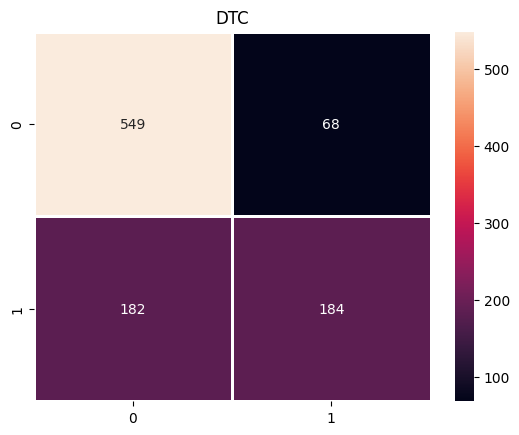

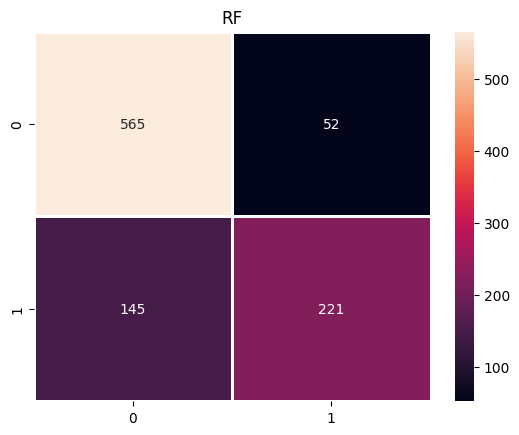

In [27]:
for name, i in cmList:
    plt.figure()
    sns.heatmap(
        i, 
        annot=True, 
        linewidths = 0.8, 
        fmt = ".0f"
    )
    plt.title(name)
    plt.show()

                TAHMİN EDİLEN SINIF
                     0           1
                +-----------+-----------+
              0 |    TN     |    FP     |
    GERÇEK      | (Doğru 0) | (Yanlış 1)|
    SINIF       +-----------+-----------+
              1 |    FN     |    TP     |
                | (Yanlış 0)| (Doğru 1) |
                +-----------+-----------+

# Evaluation
decision tree visualization

In [28]:
dt_clf = models[0][1]

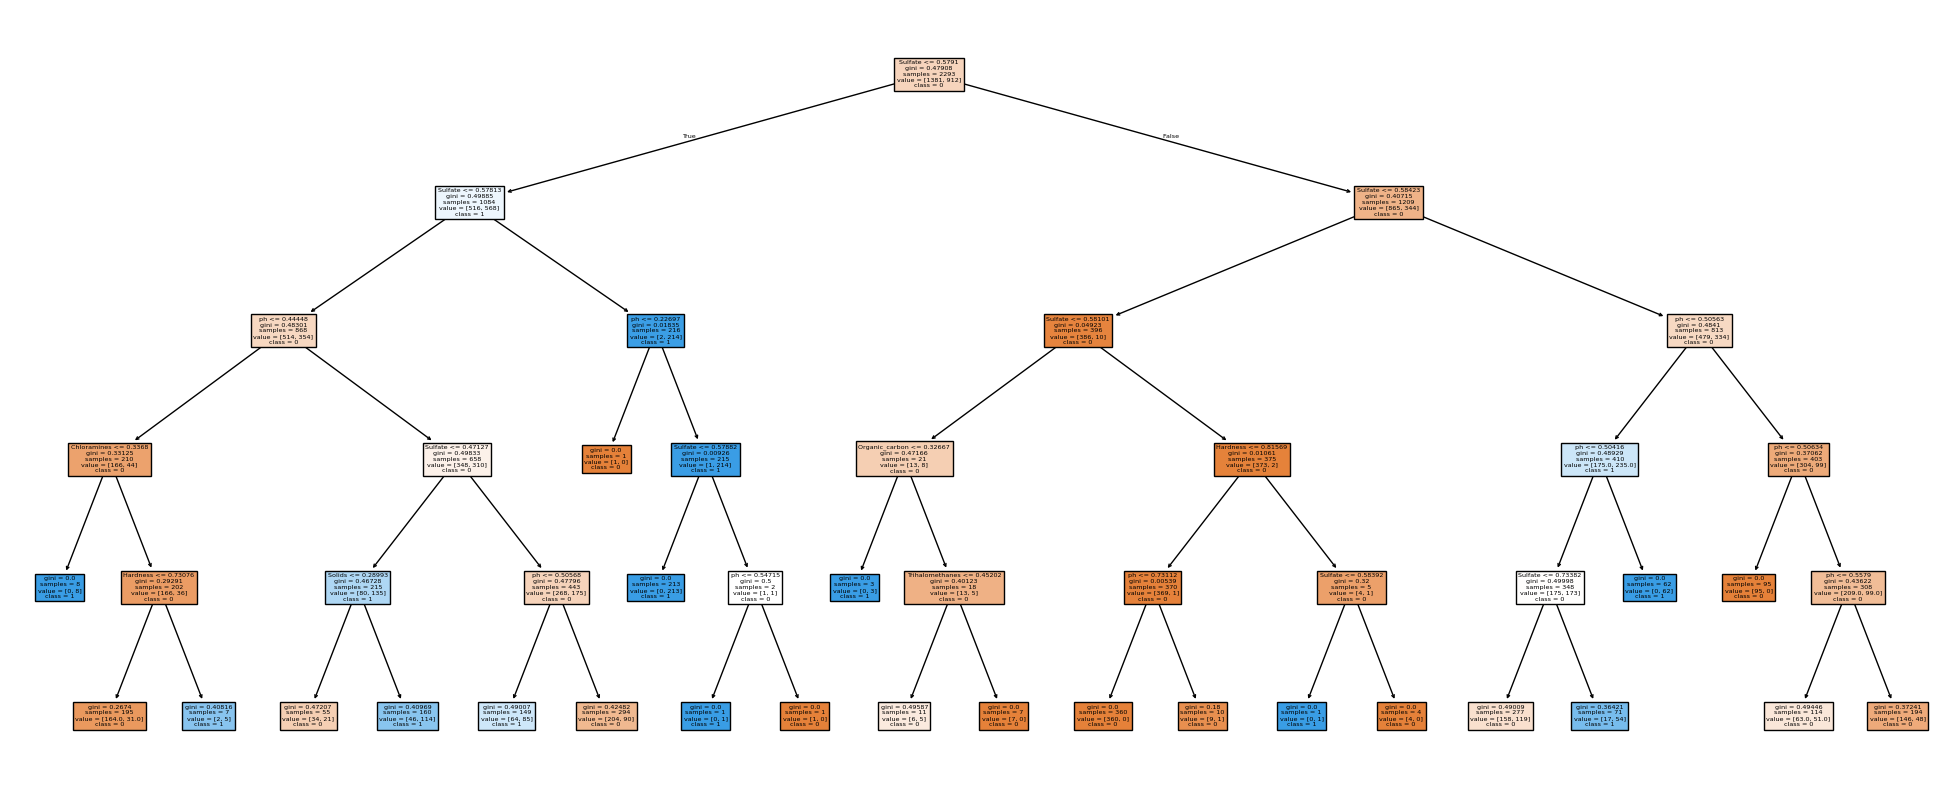

In [29]:
plt.figure(figsize = (25,10))
tree.plot_tree(
    dt_clf, 
    feature_names = df.columns.tolist()[:-1],
    class_names = ["0", "1"],
    filled = True,
    precision  = 5
)
plt.show()

# Hyperparameter tuning
Random forest

In [30]:
model_params = {
    "Random Forest": {
        "model":RandomForestClassifier(),
        "params": {
            "n_estimators": [10,50,100],
            "max_features": ["auto", "sqrt", "log2"],
            "max_depth": list(range(1,21,3))
        }
    }
}

In [31]:
cv = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 2)
scores = []

In [32]:
for model_name, params in model_params.items():
    rs = RandomizedSearchCV(
        params["model"],
        params["params"],
        cv=cv,
        n_iter = 10
    )
    rs.fit(X,y)
    scores.append([model_name, dict(rs.best_params_), rs.best_score_])
    print(scores)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning:


50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils

[['Random Forest', {'n_estimators': 50, 'max_features': 'log2', 'max_depth': 13}, np.float64(0.7945643269409793)]]


# Modeli Kayıt Etme

In [33]:
import joblib

artifact = {
    "models": dict(models),                              # {"DTC": ..., "RF": ...}
    "feature_names": df.drop("Potability", axis=1).columns.tolist(),
    "x_min": x_train_min,
    "x_max": x_train_max,
}
joblib.dump(artifact, "water_quality_artifact.joblib")

['water_quality_artifact.joblib']